In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

In [3]:
filename = "IV_defect.iv"   # put this script in the same folder as the .iv file

records = []   # list of dicts: {pal1, pal2, jsc, voc, ff, pce}

with open(filename, "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

In [4]:
i = 0
while i < len(lines):
    line = lines[i]

    # Detect a "**Batch parameters**" block
    if "**Batch parameters**" in line:
        pal1, pal2 = None, None

        # Next two lines carry the thickness values
        for offset in range(1, 5):
            if i + offset >= len(lines):
                break
            param_line = lines[i + offset]
            # PAL1 thickness
            if "PAL1" in param_line and "thickness" in param_line:
                m = re.search(r":\s*([\d.eE+\-]+)", param_line)
                if m:
                    pal1 = float(m.group(1))
            # PAL2 thickness
            if "PAL2" in param_line and "thickness" in param_line:
                m = re.search(r":\s*([\d.eE+\-]+)", param_line)
                if m:
                    pal2 = float(m.group(1))

        # Scan forward (up to 150 lines) for the solar cell parameter summary
        voc = jsc = ff = pce = None
        for j in range(i + 1, min(i + 150, len(lines))):
            sl = lines[j]
            if re.match(r"\s*Voc\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    voc = float(m.group(1))
            elif re.match(r"\s*Jsc\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    jsc = float(m.group(1))
            elif re.match(r"\s*FF\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    ff = float(m.group(1))
            elif re.match(r"\s*eta\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    pce = float(m.group(1))
            # Stop when we hit the next simulation block
            if "SCAPS 3.3" in sl and j > i + 5:
                break

        if all(v is not None for v in [pal1, pal2, voc, jsc, ff, pce]):
            records.append({
                "pal1": round(pal1, 4),
                "pal2": round(pal2, 4),
                "jsc":  jsc,
                "voc":  voc,
                "ff":   ff,
                "pce":  pce,
            })
    i += 1

print(f"✓ Parsed {len(records)} batch simulation records\n")
if not records:
    raise SystemExit("No batch records found — check file path or format.")

✓ Parsed 121 batch simulation records



In [5]:
pal1_arr = np.array([r["pal1"] for r in records])
pal2_arr = np.array([r["pal2"] for r in records])
jsc_arr  = np.array([r["jsc"]  for r in records])
voc_arr  = np.array([r["voc"]  for r in records])
ff_arr   = np.array([r["ff"]   for r in records])
pce_arr  = np.array([r["pce"]  for r in records])

print("PAL1 unique values (µm):", np.unique(pal1_arr))
print("PAL2 unique values (µm):", np.unique(pal2_arr))
print(f"\nPCE range : {pce_arr.min():.2f}% – {pce_arr.max():.2f}%")
print(f"Jsc range : {jsc_arr.min():.2f} – {jsc_arr.max():.2f} mA/cm²")
print(f"Voc range : {voc_arr.min():.3f} – {voc_arr.max():.3f} V")
print(f"FF  range : {ff_arr.min():.2f}% – {ff_arr.max():.2f}%")

PAL1 unique values (µm): [0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3]
PAL2 unique values (µm): [0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3]

PCE range : 16.96% – 24.39%
Jsc range : 30.54 – 34.51 mA/cm²
Voc range : 1.041 – 3.655 V
FF  range : 21.02% – 51.54%


In [6]:
p1_min, p1_max = pal1_arr.min(), pal1_arr.max()
p2_min, p2_max = pal2_arr.min(), pal2_arr.max()

xi = np.linspace(p1_min, p1_max, 300)
yi = np.linspace(p2_min, p2_max, 300)
XI, YI = np.meshgrid(xi, yi)

points = np.column_stack([pal1_arr, pal2_arr])

ZI_jsc = griddata(points, jsc_arr, (XI, YI), method="cubic")
ZI_voc = griddata(points, voc_arr, (XI, YI), method="cubic")
ZI_ff  = griddata(points, ff_arr,  (XI, YI), method="cubic")
ZI_pce = griddata(points, pce_arr, (XI, YI), method="cubic")


✓ Saved: PSC_PAL_thickness_contour.png


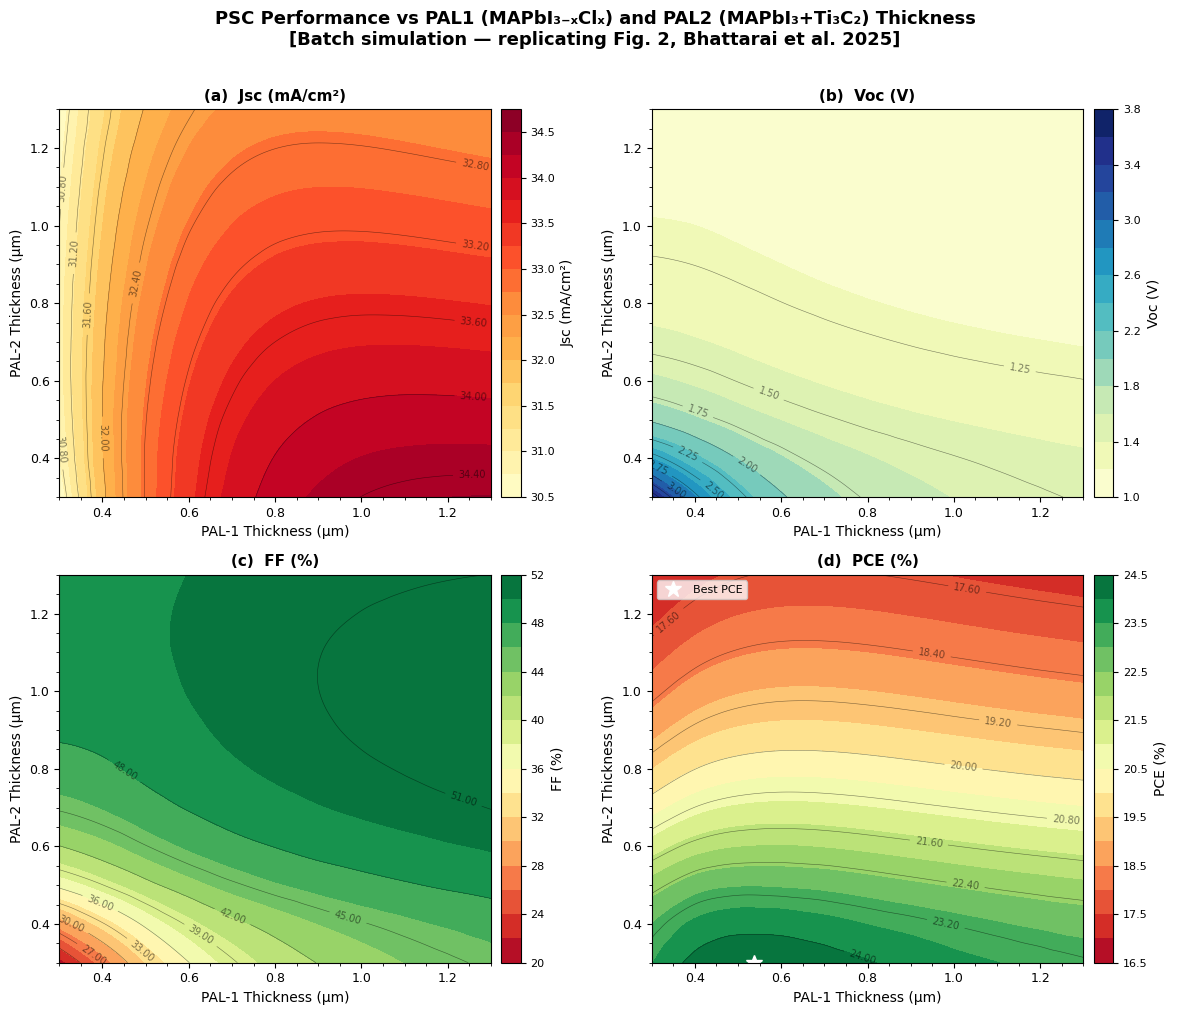

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "PSC Performance vs PAL1 (MAPbI₃₋ₓClₓ) and PAL2 (MAPbI₃+Ti₃C₂) Thickness\n"
    "[Batch simulation — replicating Fig. 2, Bhattarai et al. 2025]",
    fontsize=13, fontweight="bold", y=1.01
)

datasets = [
    (ZI_jsc, "Jsc (mA/cm²)",  "YlOrRd", "(a)"),
    (ZI_voc, "Voc (V)",        "YlGnBu", "(b)"),
    (ZI_ff,  "FF (%)",         "RdYlGn", "(c)"),
    (ZI_pce, "PCE (%)",        "RdYlGn", "(d)"),
]

for ax, (Z, label, cmap, tag) in zip(axes.flat, datasets):
    cf = ax.contourf(XI, YI, Z, levels=15, cmap=cmap)
    cs = ax.contour(XI, YI, Z, levels=10, colors="k", linewidths=0.4, alpha=0.5)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")

    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(label, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    # Mark the best point
    idx = np.nanargmax(Z) if "PCE" in label or "Jsc" in label else np.nanargmax(Z)
    best_y, best_x = np.unravel_index(idx, Z.shape) if "Voc" not in label else (0, 0)
    if "PCE" in label:
        ax.plot(XI.flat[idx], YI.flat[idx], "w*", markersize=12, label="Best PCE")
        ax.legend(fontsize=8, loc="upper left")

    ax.set_xlabel("PAL-1 Thickness (µm)", fontsize=10)
    ax.set_ylabel("PAL-2 Thickness (µm)", fontsize=10)
    ax.set_title(f"{tag}  {label}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("PSC_PAL_thickness_contour.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: PSC_PAL_thickness_contour.png")
plt.show()


In [8]:
print("\n── Parsing J-V curves for selected thickness combinations ──")

target_combos = []
for r in records:
    # grab a few representative ones: thickest PAL1, thinnest PAL2 (best PCE region)
    if abs(r["pal1"] - 1.3) < 0.05 or abs(r["pal1"] - 0.3) < 0.05:
        if abs(r["pal2"] - 0.3) < 0.05 or abs(r["pal2"] - 0.7) < 0.05 or abs(r["pal2"] - 1.3) < 0.05:
            target_combos.append((round(r["pal1"], 2), round(r["pal2"], 2)))


── Parsing J-V curves for selected thickness combinations ──


In [9]:
# Re-parse to extract J-V arrays
jv_data = {}   # key: (pal1, pal2), value: (voltages, currents)

with open(filename, "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if "**Batch parameters**" in line:
        pal1, pal2 = None, None
        for offset in range(1, 5):
            if i + offset >= len(lines): break
            pl = lines[i + offset]
            if "PAL1" in pl and "thickness" in pl:
                m = re.search(r":\s*([\d.eE+\-]+)", pl)
                if m: pal1 = round(float(m.group(1)), 2)
            if "PAL2" in pl and "thickness" in pl:
                m = re.search(r":\s*([\d.eE+\-]+)", pl)
                if m: pal2 = round(float(m.group(1)), 2)

        if (pal1, pal2) in target_combos:
            voltages, currents = [], []
            for j in range(i + 1, min(i + 200, len(lines))):
                sl = lines[j].strip()
                # Data rows: start with a number (voltage)
                parts = sl.split()
                if len(parts) >= 2:
                    try:
                        v = float(parts[0])
                        j_tot = float(parts[1])
                        # Only illuminated data has negative j at V=0
                        voltages.append(v)
                        currents.append(j_tot)
                    except ValueError:
                        pass
                if "solar cell parameters" in sl.lower():
                    break
            if voltages:
                jv_data[(pal1, pal2)] = (np.array(voltages), np.array(currents))
    i += 1

✓ Saved: PSC_JV_selected.png


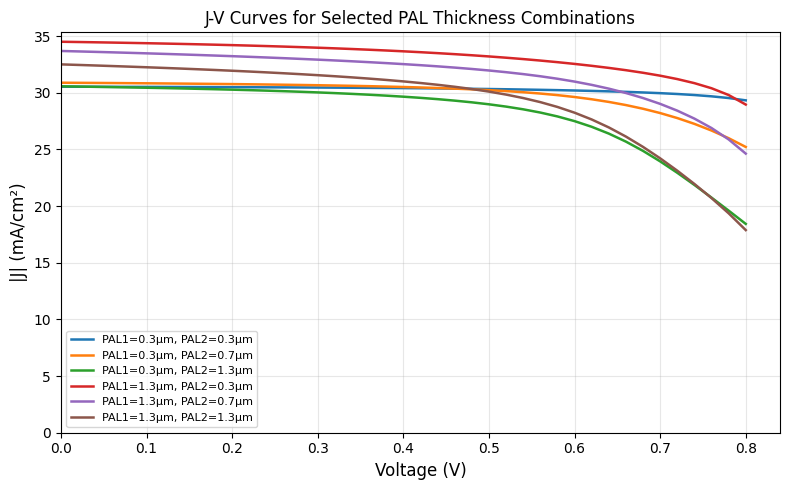


Done.


In [10]:
# Plot J-V curves
if jv_data:
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(jv_data)))

    for (p1, p2), (v, j) in sorted(jv_data.items()):
        # Only plot illuminated region (j < 0 means photocurrent)
        mask = j <= 0
        if mask.sum() > 3:
            ax2.plot(v[mask], np.abs(j[mask]),
                     label=f"PAL1={p1}µm, PAL2={p2}µm",
                     linewidth=1.8)

    ax2.set_xlabel("Voltage (V)", fontsize=12)
    ax2.set_ylabel("|J| (mA/cm²)", fontsize=12)
    ax2.set_title("J-V Curves for Selected PAL Thickness Combinations", fontsize=12)
    ax2.legend(fontsize=8, loc="lower left")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    ax2.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig("PSC_JV_selected.png", dpi=300, bbox_inches="tight")
    print("✓ Saved: PSC_JV_selected.png")
    plt.show()
else:
    print("(No matching J-V curves found for selected combos — skipping J-V plot)")

print("\nDone.")